# E-Commerce Sales & Customer Analytics Dashboard

## Project Overview

This project analyzes over 540,000 online retail transactions to identify customer purchasing behavior, product performance, and revenue trends.

Using Python, SQL, and Tableau, the project aims to generate actionable business insights through KPI analysis and dashboard development.

## Business Questions

1. What is the overall sales performance of the business?
2. Which products generate the highest revenue?
3. Which countries contribute most to sales?
4. How does revenue change over time?
5. Who are the most valuable customers?

# Dataset Overview

## Dataset Information

The dataset contains online retail transactions from a UK-based e-commerce company.

### Key Variables

| Variable | Description |
|-----------|-------------|
| InvoiceNo | Transaction ID |
| StockCode | Product Code |
| Description | Product Description |
| Quantity | Number of Items Purchased |
| InvoiceDate | Date of Transaction |
| UnitPrice | Price Per Item |
| CustomerID | Customer Identifier |
| Country | Customer Country |

---

## Dataset Size

This dataset contains more than 540,000 transaction records and represents real-world customer purchasing behavior.

# Data Loading

The first step is to load the dataset and inspect its structure.

Initial exploration helps identify:

- Dataset dimensions
- Data types
- Missing values
- Potential quality issues

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/online_retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Initial Data Inspection

Before performing any analysis, it is important to understand the dataset structure and evaluate data quality.

The following checks are performed:

1. Dataset dimensions
2. Column data types
3. Missing values
4. Summary statistics

In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Data Cleaning

Raw transactional data often contains invalid or incomplete records.

To improve data quality, the following steps are performed:

1. Remove canceled orders
2. Remove negative quantities
3. Remove invalid prices
4. Create a Revenue variable

These steps ensure that only valid sales transactions are included in the analysis.

In [6]:
df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Data Cleaning Results

After cleaning the dataset, the number of valid transactions is recalculated.

The cleaned dataset will serve as the foundation for all subsequent analyses.

In [7]:
df.shape

(530104, 9)

# KPI Analysis

Key Performance Indicators (KPIs) provide a high-level overview of business performance.

The following metrics are calculated:

- Total Revenue
- Total Orders
- Total Customers
- Average Order Value (AOV)

These metrics help evaluate overall sales performance and customer purchasing behavior.

In [8]:
total_revenue = df["Revenue"].sum()

total_orders = df["InvoiceNo"].nunique()

total_customers = df["CustomerID"].nunique()

aov = total_revenue / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value (AOV): ${aov:,.2f}")

Total Revenue: $10,666,684.54
Total Orders: 19,960
Total Customers: 4,338
Average Order Value (AOV): $534.40


In [9]:
kpi_df = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value"
    ],
    "Value": [
        round(total_revenue, 2),
        total_orders,
        total_customers,
        round(aov, 2)
    ]
})

kpi_df

,Metric,Value
0,Total Revenue,10666684.54
1,Total Orders,19960.00
2,Total Customers,4338.00
3,Average Order Value,534.40


# Revenue Trend Analysis

Understanding sales performance over time helps identify growth patterns, seasonality, and business opportunities.

This section analyzes monthly revenue trends throughout the observation period.

In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Month,Revenue
0,2010-12,823746.140
1,2011-01,691364.560
2,2011-02,523631.890
3,2011-03,717639.360
4,2011-04,537808.621


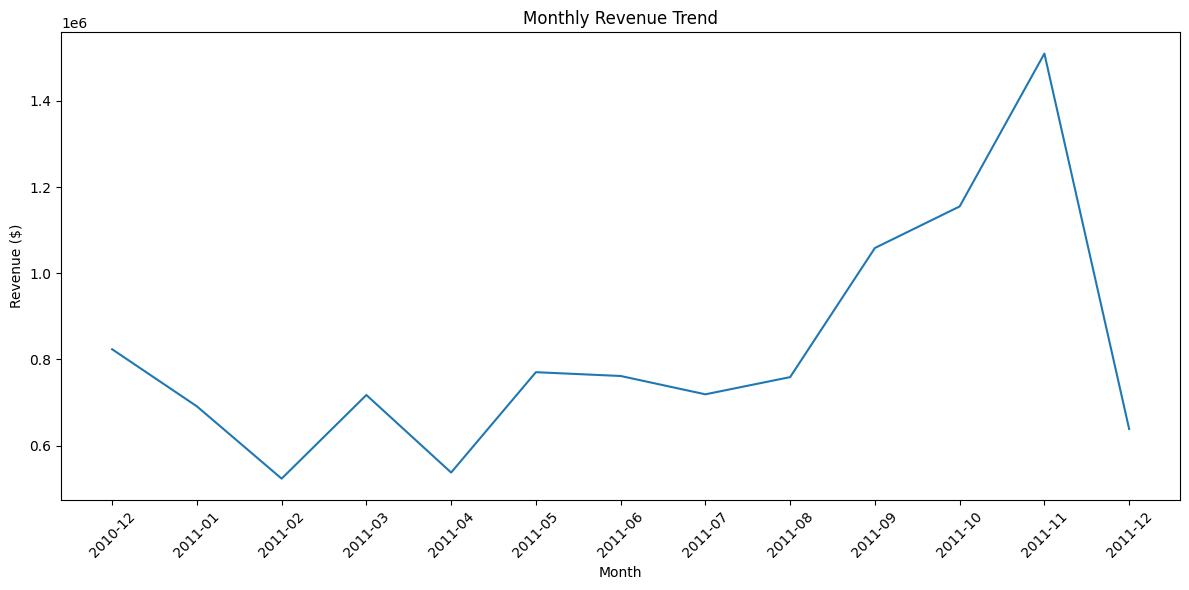

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Month"].astype(str),
    monthly_sales["Revenue"]
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

plt.tight_layout()

plt.show()

## Key Findings

### Revenue Growth

Revenue remained relatively stable during the first half of 2011 but increased significantly during the final quarter of the year.

### Seasonal Demand

The highest monthly revenue was observed in November 2011, suggesting strong seasonal demand associated with holiday shopping periods.

### Data Limitation

Revenue appears to decline sharply in December 2011; however, the dataset only contains partial December data, making direct comparison unreliable.

# Product Performance Analysis

Understanding which products generate the most revenue helps identify key revenue drivers and potential merchandising opportunities.

This analysis evaluates the highest-performing products based on total sales revenue.

In [12]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Revenue, dtype: float64

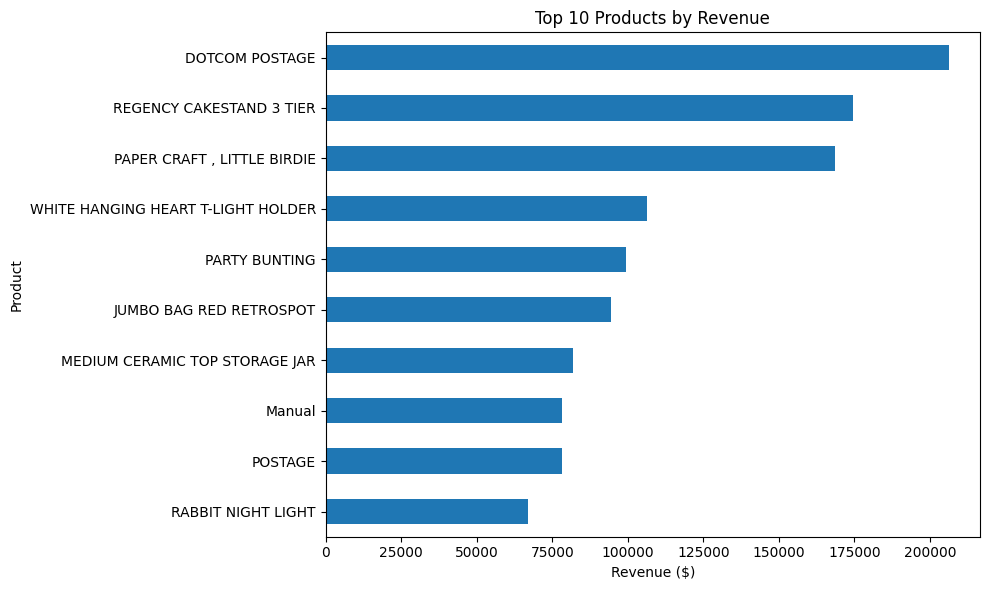

In [13]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

# Geographic Analysis

Understanding geographic sales distribution helps identify key markets and growth opportunities.

This analysis evaluates revenue performance across countries.

In [14]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

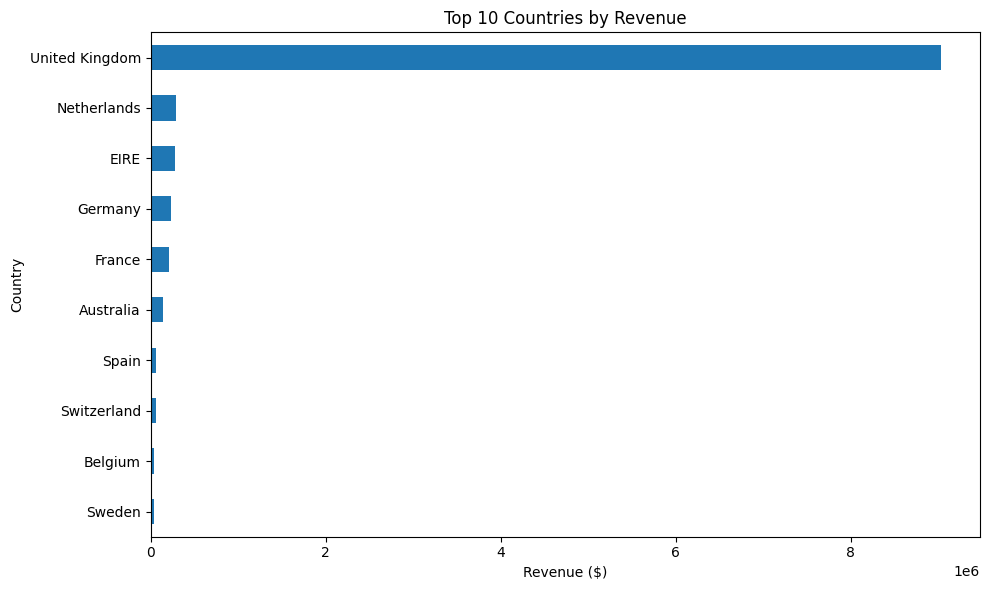

In [15]:
plt.figure(figsize=(10,6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [16]:
country_sales_no_uk = (
    df[df["Country"] != "United Kingdom"]
      .groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales_no_uk

Country
Netherlands    285446.34
EIRE           283453.96
Germany        228867.14
France         209715.11
Australia      138521.31
Spain           61577.11
Switzerland     57089.90
Belgium         41196.34
Sweden          38378.33
Japan           37416.37
Name: Revenue, dtype: float64

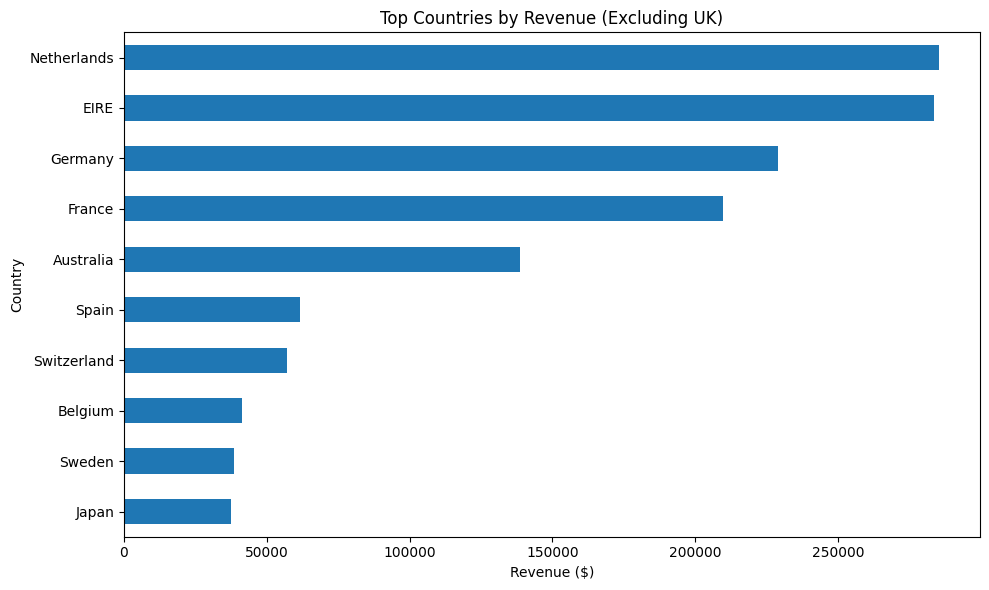

In [17]:
plt.figure(figsize=(10,6))

country_sales_no_uk.sort_values().plot(kind="barh")

plt.title("Top Countries by Revenue (Excluding UK)")
plt.xlabel("Revenue ($)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

# Customer Segmentation (RFM Analysis)

Customer segmentation helps businesses understand purchasing behavior and identify high-value customer groups.

RFM analysis evaluates customers based on:

- Recency: How recently a customer made a purchase
- Frequency: How often a customer makes purchases
- Monetary: How much revenue a customer generates

The objective is to identify valuable customers and support targeted marketing strategies.

In [18]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [19]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [20]:
champions = rfm[
    (rfm["R_Score"] == 4) &
    (rfm["F_Score"] == 4) &
    (rfm["M_Score"] == 4)
]

champions.shape[0]

490

In [21]:
segment_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Champion Customers"
    ],
    "Value": [
        len(rfm),
        len(champions)
    ]
})

segment_summary

,Metric,Value
0,Total Customers,4338
1,Champion Customers,490


In [25]:
def segment_customer(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"
    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"
    elif row["R_Score"] >= 3 and row["F_Score"] <= 2:
        return "Potential Loyalists"
    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

segment_counts = rfm["Segment"].value_counts()
segment_counts

Segment
Others                 1504
Loyal Customers        1033
Potential Loyalists     665
At Risk                 646
Champions               490
Name: count, dtype: int64

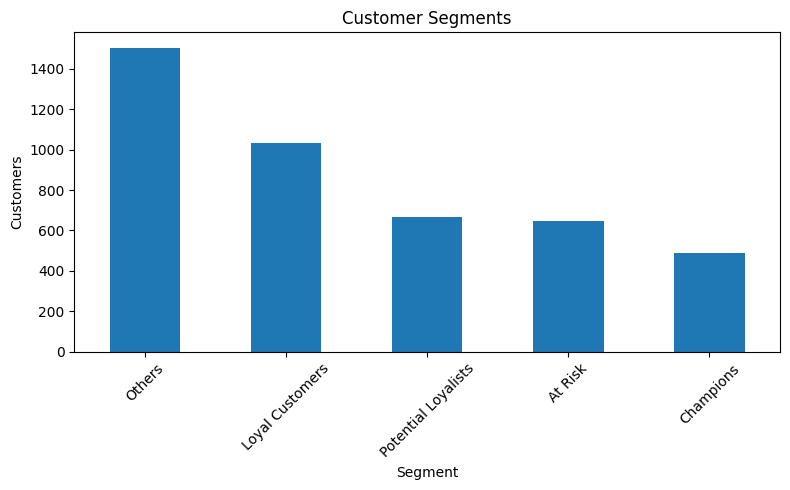

In [26]:
plt.figure(figsize=(8,5))

segment_counts.plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)

rfm.to_csv("customer_segments.csv")